In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import logging
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from xgboost import plot_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

In [74]:
od = pd.read_csv("data/Order.csv",encoding='latin-1')
rt = pd.read_csv("data/Return.csv", encoding ='latin-1')
pp = pd.read_csv("data/People.csv", encoding='latin-1')

In [75]:
od.shape

(51290, 24)

In [76]:
rt.shape

(1079, 3)

In [77]:
pp.shape

(24, 2)

In [78]:
od.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   Postal Code     9994 non-null   float64
 9   City            51290 non-null  str    
 10  State           51290 non-null  str    
 11  Country         51290 non-null  str    
 12  Region          51290 non-null  str    
 13  Market          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [79]:
od.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,$221.98,2,0.0,$62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black","$3,709.40",9,0.1,($288.77),923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID","$5,175.17",9,0.1,$919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless","$2,892.51",5,0.1,($96.54),910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed","$2,832.96",8,0.0,$311.52,903.04,Critical
5,22732,IN-2014-JM156557-41818,6/28/2014,7/1/2014,Second Class,JM-156557,Jim Mitchum,Corporate,NaN,Sydney,...,TEC-PH-5842,Technology,Phones,"Samsung Smart Phone, with Caller ID","$2,862.68",5,0.1,$763.28,897.35,Critical
6,30570,IN-2012-TS2134092-41219,11/6/2012,11/8/2012,First Class,TS-2134092,Toby Swindell,Consumer,NaN,Porirua,...,FUR-CH-5378,Furniture,Chairs,"Novimex Executive Leather Armchair, Adjustable","$1,822.08",4,0.0,$564.84,894.77,Critical
7,31192,IN-2013-MB1808592-41378,4/14/2013,4/18/2013,Standard Class,MB-1808592,Mick Brown,Consumer,NaN,Hamilton,...,FUR-TA-3764,Furniture,Tables,"Chromcraft Conference Table, Fully Assembled","$5,244.84",6,0.0,$996.48,878.38,High
8,40099,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,FUR-BO-5957,Furniture,Bookcases,"Sauder Facets Collection Library, Sky Alder Fi...",$341.96,2,0.0,$54.71,25.27,High
9,36258,CA-2012-AB10015140-40974,3/6/2012,3/7/2012,First Class,AB-100151404,Aaron Bergman,Consumer,98103.0,Seattle,...,FUR-CH-4421,Furniture,Chairs,"Global Push Button Manager's Chair, Indigo",$48.71,1,0.2,$5.48,11.13,High


In [80]:
od.isna().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Postal Code       41296
City                  0
State                 0
Country               0
Region                0
Market                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [81]:
od.duplicated().sum()

np.int64(0)

Làm sạch dữ liệu tiền

In [82]:
def clean_money(col):
    col = col.astype(str)
    col = col.str.replace('$', '', regex=False)
    col = col.str.replace(',', '', regex=False)
    col = col.str.replace('(', '-', regex=False)
    col = col.str.replace(')', '', regex=False)
    col = col.str.strip()
    return pd.to_numeric(col, errors='coerce')

for col in ['Sales', 'Profit', 'Shipping Cost']:
    od[col] = clean_money(od[col])

In [83]:
od1 = od.drop(columns=['Row ID', 'Postal Code'])
columns_to_show = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
od1[columns_to_show].describe()

,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.490685,3.476545,0.142908,28.610970,26.478567
std,487.565388,2.278766,0.212280,174.341066,57.251373
min,0.440000,1.000000,0.000000,-6599.980000,1.002000
25%,30.762500,2.000000,0.000000,0.000000,2.610000
50%,85.055000,3.000000,0.000000,9.240000,7.790000
75%,251.055000,5.000000,0.200000,36.810000,24.450000
max,22638.480000,14.000000,0.850000,8399.980000,933.570000


BẢNG THỐNG KÊ MÔ TẢ


 Quantity:
 - Trung bình 3-4 sản phẩm/đơn
-> Đơn hàng nhỏ lẻ

Discount:
 - Trung bình là ~14% nhưng median = 0 -> Phần lớn đơn hàng không có giảm giá
 - Nhưng max = 85% -> Sẽ có nhưng đơn hàng giảm giá rất cao

Shipping Cost:
 - Trung bình ~26 nhưng median chỉ ~7.8 -> Dữ liệu lệch phải
 - Max = 933 -> Đơn hàng cho chi phí vận chuyển bất thường

In [84]:
od.describe(include=['object', 'string'])

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Region,Market,Product ID,Category,Sub-Category,Product Name,Order Priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25728,1430,1464,4,17415,796,3,3650,1102,165,23,5,3788,3,17,3788,4
top,CA-2015-SV20365140-42268,6/18/2015,11/22/2015,Standard Class,SV-203651406,Muhammed Yedwab,Consumer,New York City,California,United States,Western Europe,Asia Pacific,OFF-FA-6129,Office Supplies,Binders,Staples,Medium
freq,14,135,130,30775,26,108,26518,915,2001,9994,5883,14302,227,31289,6146,227,29433


Thống kê doanh thu theo Danh mục hàng hóa

In [85]:
sales_stats = od.groupby('Sub-Category')['Sales'].agg(
    Count='count',
    Mean=('mean'),
    Median='median',
    Min='min',
    Max='max'
)

sales_stats['Mean'] = sales_stats['Mean'].round(3)
sales_stats['Median'] = sales_stats['Median'].round(3)

print("\n--- Thống kê theo Danh mục hàng hóa ---")
print(sales_stats)


--- Thống kê theo Danh mục hàng hóa ---
              Count     Mean   Median    Min       Max
Sub-Category                                          
Accessories    3075  243.654  132.500   0.99   3449.88
Appliances     1742  580.101  251.485   0.44   7958.58
Art            4864   76.401   50.100   1.34   1113.02
Binders        6146   75.150   28.230   0.56   9892.74
Bookcases      2411  608.284  411.330  35.49   5667.87
Chairs         3434  437.298  258.000  13.55   5759.96
Copiers        2223  679.009  487.380  35.46  17499.95
Envelopes      2387   70.891   48.030   1.63    604.66
Fasteners      2601   34.408   25.870   1.24    271.32
Furnishings    3154  122.117   73.720   1.89   1519.14
Labels         2601   28.201   20.650   1.67    786.48
Machines       1486  524.267  305.145  11.51  22638.48
Paper          3492   69.240   43.820   3.38    733.95
Phones         3357  508.437  273.300   2.97   6998.64
Storage        5049  223.176  113.820   2.80   2962.68
Supplies       2407  100

Thống kê doanh thu theo phân khúc

In [86]:
sales_stats = od.groupby('Segment')['Sales'].agg(
    Count='count',
    Mean=('mean'),
    Median='median',
    Min='min',
    Max='max'
)

sales_stats['Mean'] = sales_stats['Mean'].round(3)
sales_stats['Median'] = sales_stats['Median'].round(3)

print("\n--- Thống kê theo phân khúc ---")
print(sales_stats)


--- Thống kê theo phân khúc ---
             Count     Mean  Median   Min       Max
Segment                                            
Consumer     26518  245.416  85.005  0.44  13999.96
Corporate    15429  247.890  85.440  0.56  17499.95
Home Office   9343  247.229  84.600  0.99  22638.48


Biểu đồ histogram của biến Sales.

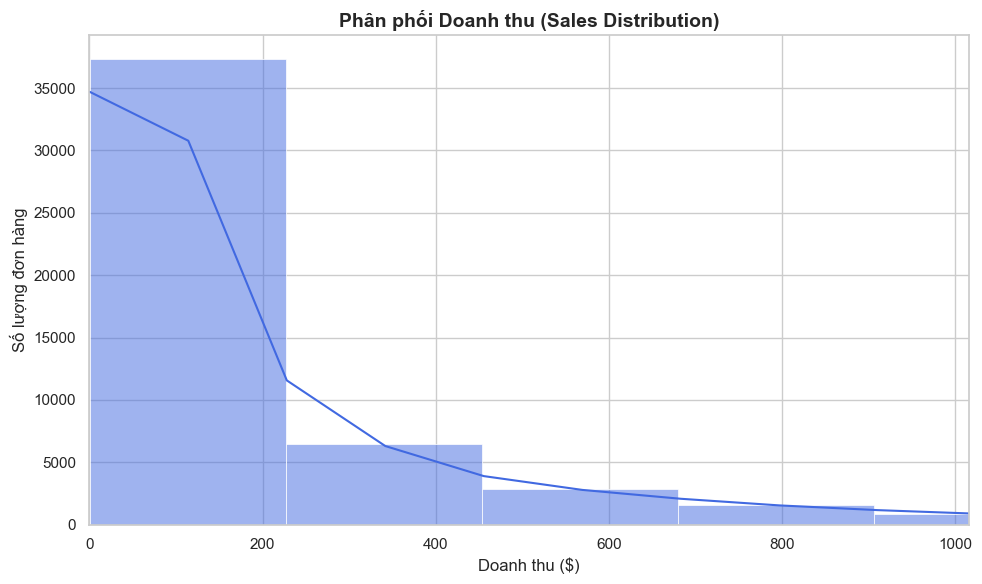

In [87]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Sales'], bins=100, kde=True, color='royalblue')
plt.title('Phân phối Doanh thu (Sales Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Doanh thu ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(0, od['Sales'].quantile(0.95))
plt.tight_layout()

plt.show()

- Biểu đồ Histogram của Doanh thu cho thấy sự phân bố không đồng đều. Số lượng đơn hàng tập trung nhiều ở phân khúc có giá trị thấp( dưới 200$), trong khi các đơn hàng có giá trị cao có số lượng rất ít kéo dài về phía bên phải.
- Điều này phản ánh mô hình bán lẻ phổ biến: nhiều đơn nhỏ, ít đơn lớn.

Biểu đồ boxplot của biến Sales.

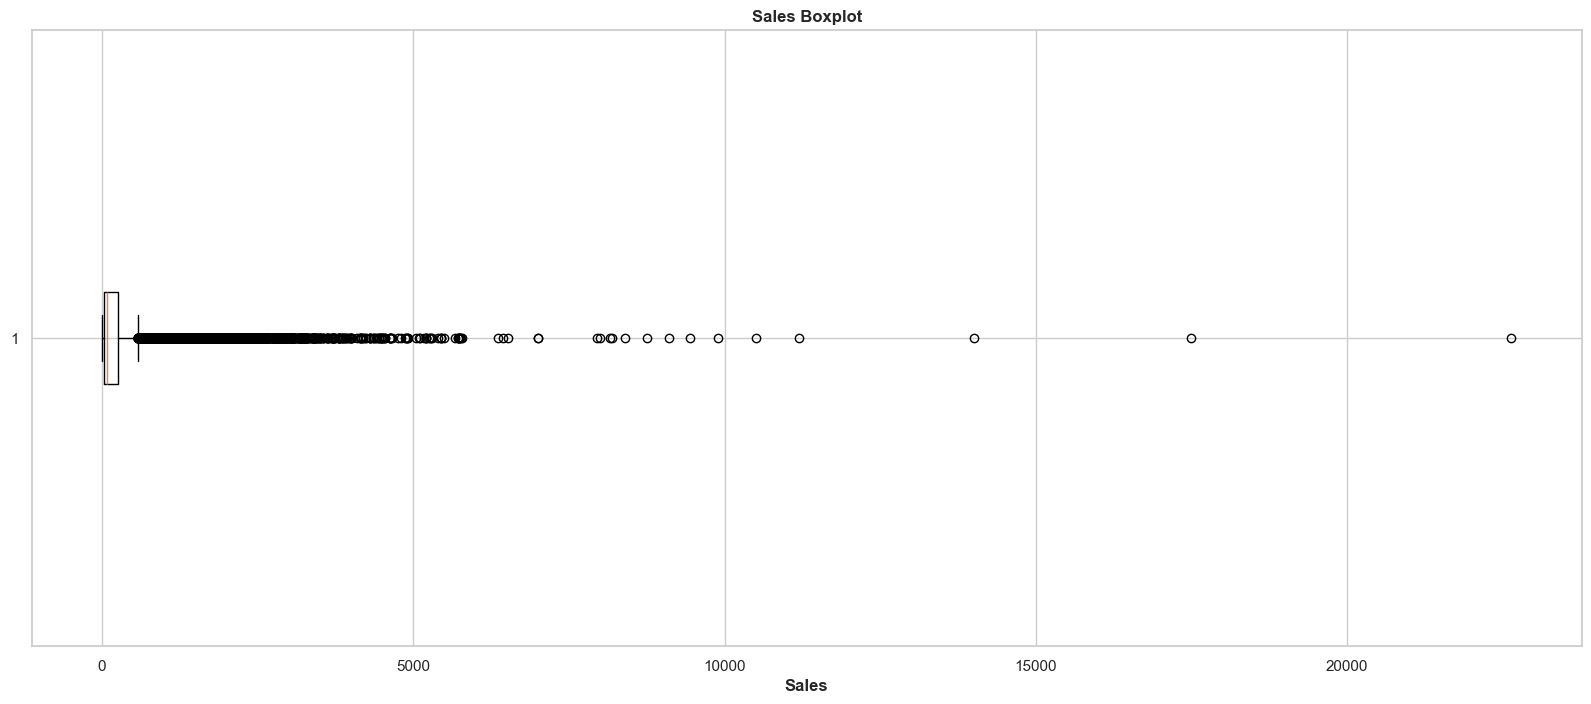

In [88]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Sales'],vert=False)
plt.title('Sales Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Sales', fontsize=12, fontweight='bold')
plt.show()

- Phân phối doanh thu có xu hướng lệch phải, với phần lớn đơn hàng có giá trị thấp.
- Một số ít đơn hàng có giá trị rất cao tạo ra nhiều outlier.
- Độ phân tán(IQR) lớn -> Sales biến động mạnh giữa các đơn hàng

Biểu đồ histogram của biến Profit.

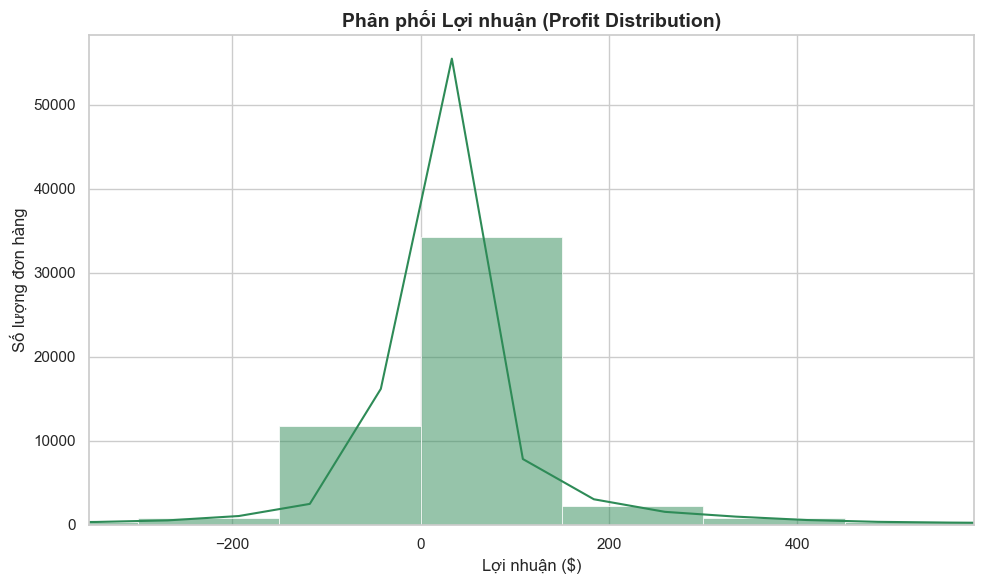

In [89]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Profit'], bins=100, kde=True, color='seagreen')
plt.title('Phân phối Lợi nhuận (Profit Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Lợi nhuận ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(od['Profit'].quantile(0.01), od['Profit'].quantile(0.99))
plt.tight_layout()

plt.show()

- Dữ liệu phân bố quanh mức gần 0 -> Nhiều đơn hàng không có lãi thậm chí âm. Điều này phản ảnh hiệu qu kinh doanh không đồng đều giữa các đơn hàng, doanh nghiệp cần xem xét lại ngay vì mức lợi nhuận này rất báo động.

Biểu đồ boxplot của biến Profit.

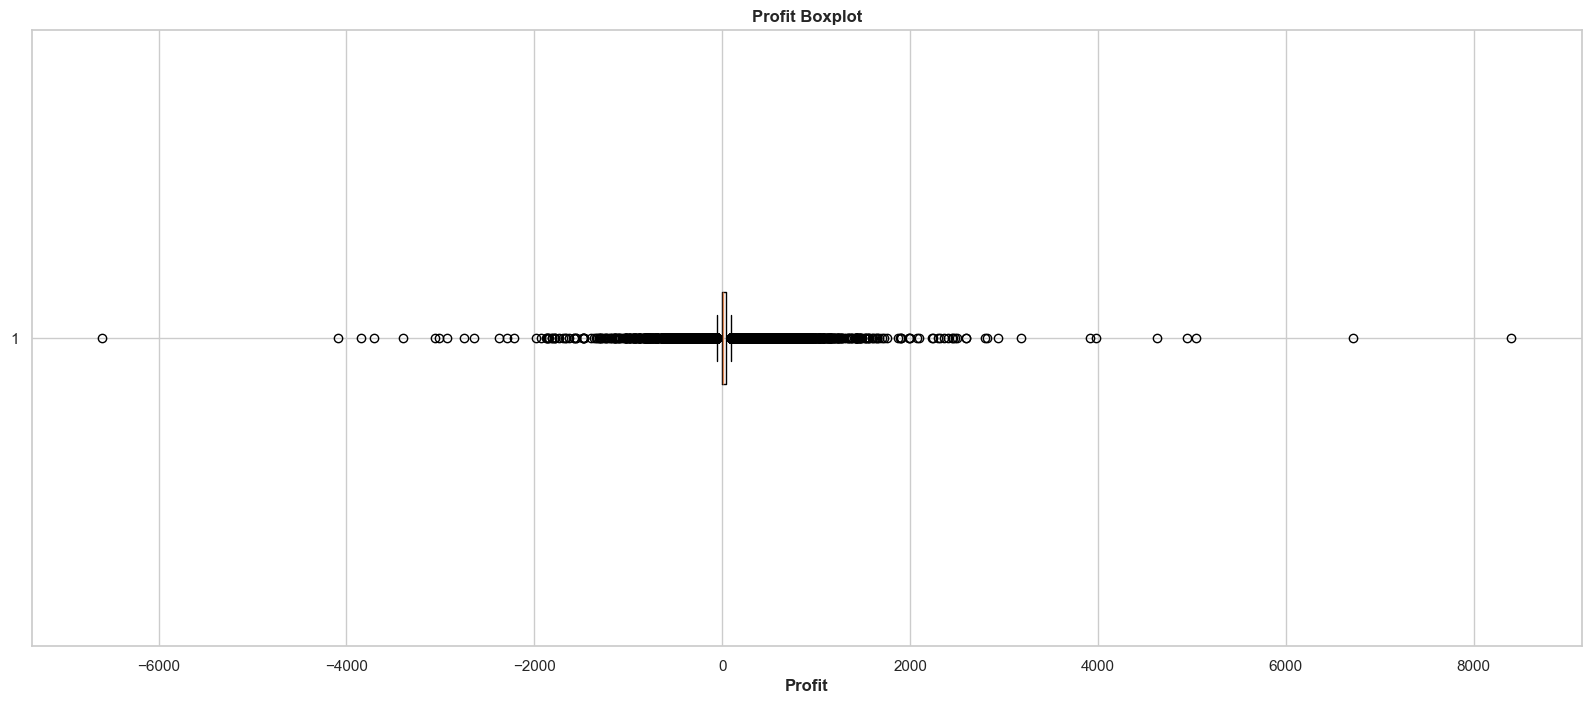

In [90]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Profit'],vert=False)
plt.title('Profit Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Profit', fontsize=12, fontweight='bold')
plt.show()

- Median Profit giữa các nhóm có sự khác biệt rõ rệt.
- Có nhiều outlier âm, đặc biệt ở một số nhóm sản phẩm.
- Một số nhóm có IQR rộng → lợi nhuận biến động mạnh.

Biểu đồ histogram của biến Shipping Cost

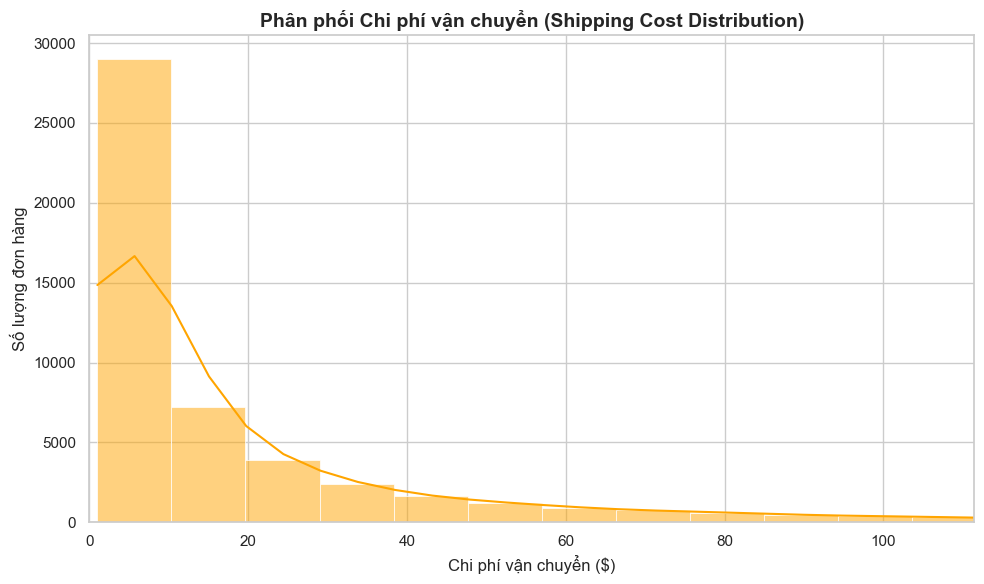

In [91]:
plt.figure(figsize=(10, 6))
sns.histplot(od['Shipping Cost'], bins=100, kde=True, color='orange')
plt.title('Phân phối Chi phí vận chuyển (Shipping Cost Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Chi phí vận chuyển ($)')
plt.ylabel('Số lượng đơn hàng')
plt.xlim(0, od['Shipping Cost'].quantile(0.95))
plt.tight_layout()

plt.show()

- Phần lớn đơn hàng có chi phí vận chuyển thấp
- Bên cạnh đó xuất hiện nhiều đơn hàng có giá trị vận chuyển cao, tăng đột biến.

Biểu đồ boxplot của biến Shipping Cost.

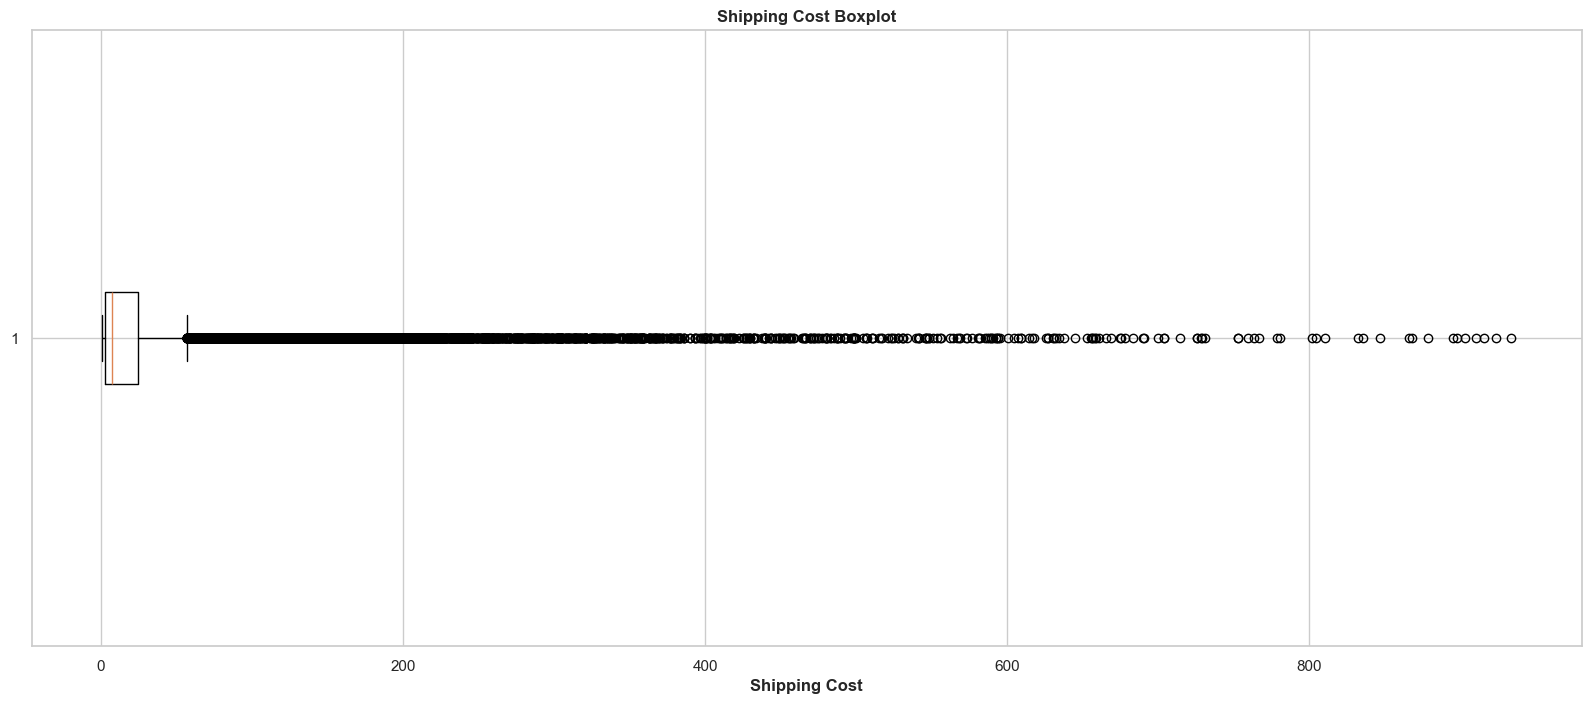

In [92]:
plt.figure(figsize=(20, 8))
plt.boxplot(od['Shipping Cost'],vert=False)
plt.title('Shipping Cost Boxplot', fontsize=12, fontweight='bold')
plt.xlabel('Shipping Cost', fontsize=12, fontweight='bold')
plt.show()

- Phần lớn đơn hàng có chi phí vận chuyển rất rẻ
- Xuất hiện nhiều outliers -> Nhiều đơn hàng có chi phí vận chuyển đột biến. Điều này có thể rơi vào:
    + Đơn hàng quốc tế
    + Hàng hóa cồng kềnh
    + Giao hàng hỏa tốc

-> Kết hợp với biểu đồ lợi nhuận bên trên thì dải chi phí vận chuyển tăng cao này là nguyên nhân nhiều đơn hàng có lỗ lớn

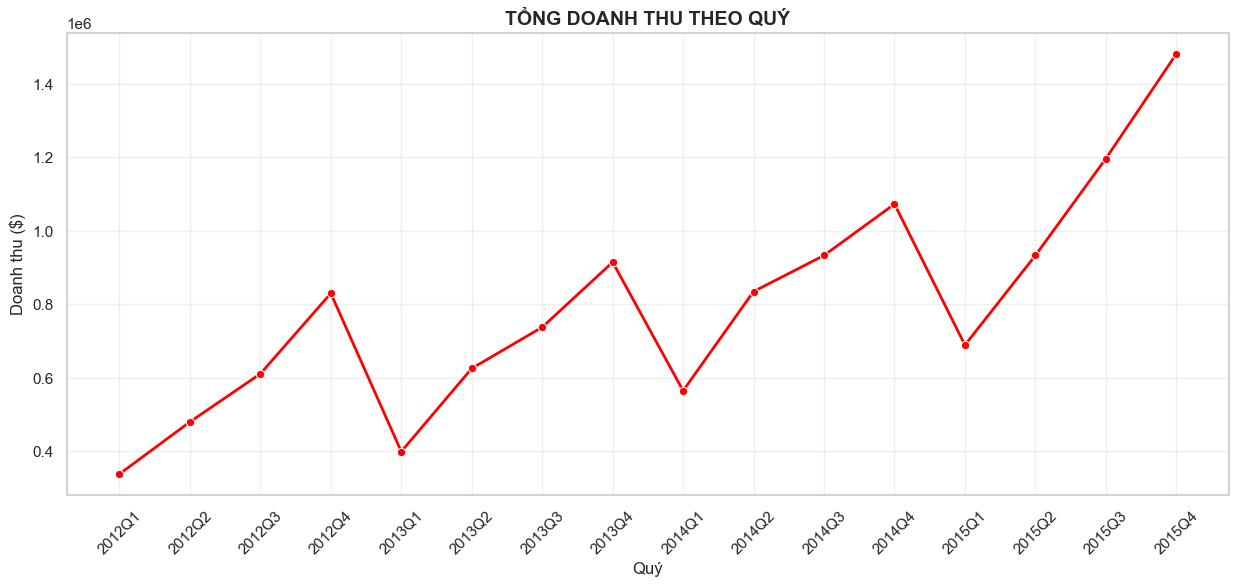

In [93]:
od['Order Date'] = pd.to_datetime(od['Order Date'])
od['Quarter'] = od['Order Date'].dt.to_period('Q').astype(str)
df_quy = od.groupby('Quarter')['Sales'].sum().reset_index()
od['Quarter'] = od['Order Date'].dt.to_period('Q').astype(str)
df_quy = od.groupby('Quarter')['Sales'].sum().reset_index()
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_quy, x='Quarter', y='Sales', marker='o', color='red', linewidth=2)
plt.title('TỔNG DOANH THU THEO QUÝ', fontsize=14, fontweight='bold')
plt.xlabel('Quý')
plt.ylabel('Doanh thu ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

- Tổng doanh thu có sự đi lên rõ rột qua các năm 2012 đến 2015 ( Từ 400k  đến  1.5M )
- Doanh thu luôn sụt giảm mạnh vào quý 1 hằng năm và tăng vọt vào quý 4 ( vì cuối năm thường sẽ có các sự kiến mua sắm lớn như Black Friday, Giáng sinh, Năm mới )

-> BIỂU ĐỒ DOANH THU THEO QUÝ GIAI ĐOẠN 2012 - 2015 CHO THẤY SỰ TĂNG TRƯỞNG TÍCH CỰC VỀ QUY MÔ. HOẠT ĐỘNG KINH DOANH MANG TÍNH MÙA VỤ VỚI ĐỈNH DOANH THU RƠI VÀO CUỐI NĂM. ĐÂY LÀ CƠ SỞ ĐỂ DOANH NGHIỆP LẬP KẾ HOẠCH DỰ TRỮ HÀNG HÓA VÀ CHUẨN BỊ NHÂN SỰ CHO CÁC GIAI ĐOẠN CAO ĐIỂM.

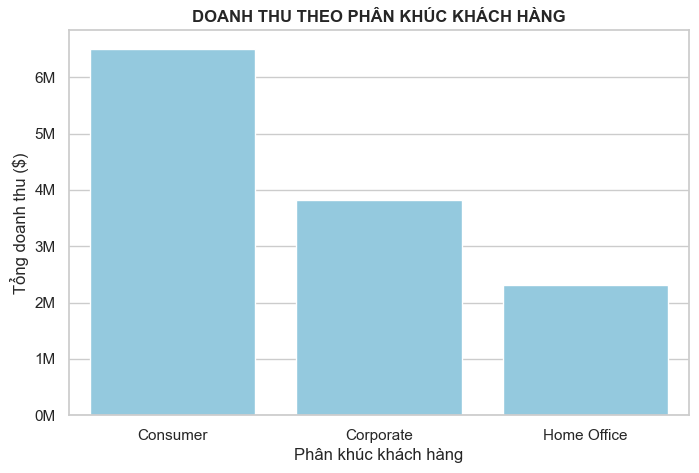

In [94]:
segment_revenue = od.groupby('Segment')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_revenue, x='Segment', y='Sales', color='skyblue')
plt.title('DOANH THU THEO PHÂN KHÚC KHÁCH HÀNG', fontsize=12, fontweight='bold')
plt.xlabel('Phân khúc khách hàng')
plt.ylabel('Tổng doanh thu ($)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(int(x/1e6))))
plt.show()

- Consumer đóng góp doanh thu cao nhất ( vượt 6M USD). Điều này cho thấy việc kinh doanh đang tập trung mạnh vào bán lẻ cá nhân tuy nhiên có sự mất cân bằng so với 2 nhóm còn lại là Corporate và Home Office

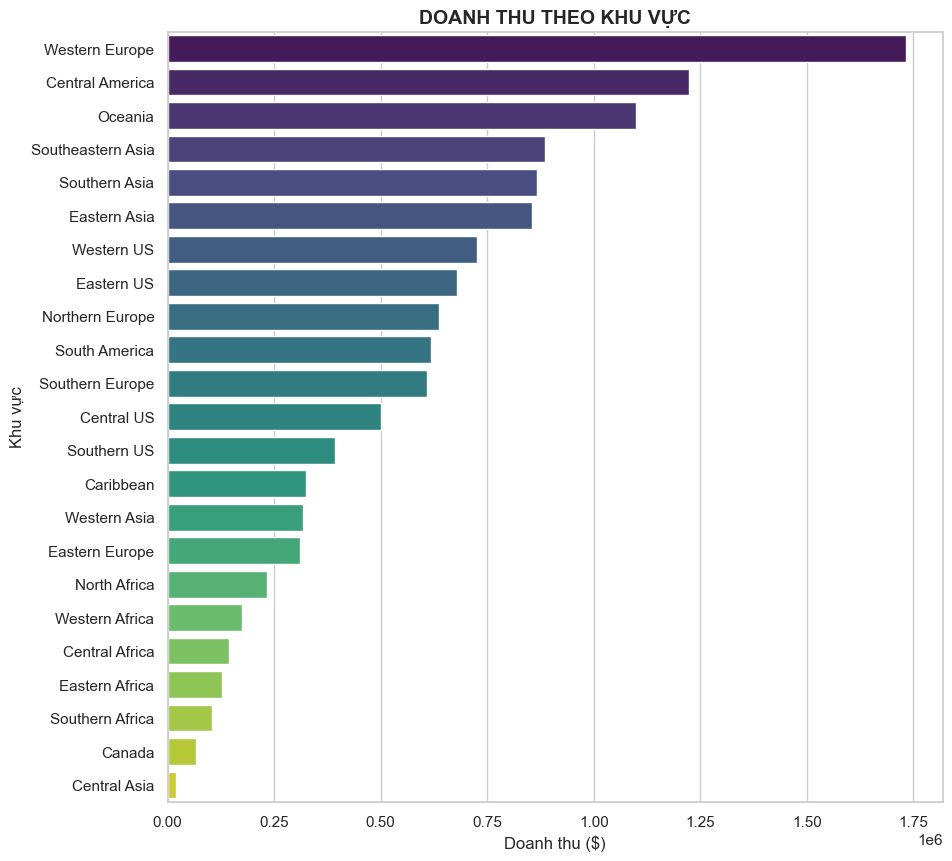

In [95]:
region_sales = od.groupby('Region')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(10, 10))
sns.barplot(data=region_sales, x='Sales', y='Region', palette='viridis', hue='Region')
plt.title('DOANH THU THEO KHU VỰC', fontsize=14, fontweight='bold')
plt.xlabel('Doanh thu ($)')
plt.ylabel('Khu vực')
plt.show()

- Khu vực Western Europe (Tây Âu) mang lại doanh thu cao nhất (gần 1.75M USD) cách khá xa 2 khu vực sau là Central American và Oceania. Cho thấy đây là những thị trường ổn định và có sức mua cao trong hệ thống
- Các khu vực thuộc châu Á đang nằm ở nhóm giữa, cho thấy cơ hội thâm nhập vào thị trường này dang ổn định và có khả năng trở thành trụ cột trong tương lai
- Sự chênh lệnh giữa nhóm đầu và nhóm cuối, điều này cho thấy sự phát triển không đồng đều giữa các thị trường trên toàn cầu
- Doanh thu thấp ở khu vực Canada nằm tại khu vực châu Mĩ cho thấy có thể có rào cản về logistic, sự cạnh tranh nội địa tại khu vực này
- Doanh thu tại Mỹ bị chia nhỏ thành nhiều vùng khiến cho thị trường này trên biểu đồ trông có vẻ thấp hơn so với thực tế tổng thể.

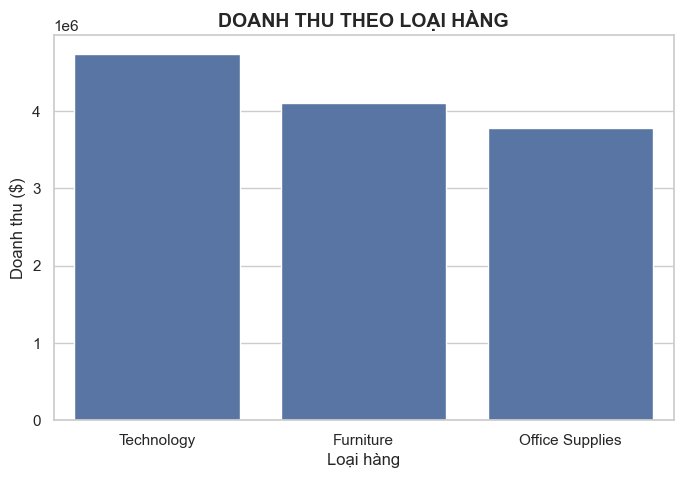

In [96]:
category_sales = od.groupby('Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(data=category_sales, x='Category', y='Sales')
plt.title('DOANH THU THEO LOẠI HÀNG', fontsize=14, fontweight='bold')
plt.xlabel('Loại hàng')
plt.ylabel('Doanh thu ($)')
plt.show()

- Doanh thu giữa 3 nhóm ngành hàng khá đồng đều (khoảng từ 3.7M - 4.7M USD)
- Hàng Technology (Công nghệ) chiếm doanh thu cao nhất phản ánh xu hướng thị trường khi các sản phẩm công nghệ thường có đơn giá cao và nhu cầu lớn trên quy mô toàn cầu.
- Ngành hàng Furniture (Nội thất) đứng thứ hai với doanh thu hơn 4.1 triệu USD. Tuy nhiên, đây là nhóm hàng đặc thù thường có chi phí vận chuyển và tỷ lệ hoàn trả cao, nên doanh thu lớn chưa chắc đã đi kèm với lợi nhuận cao nhất
- Nhóm ngành Office Supplies (Văn phòng phẩm) đứng thứ cuối nhưng đây thường là nhóm có số lượng đơn hàng lớn nhất. Các mặt hàng này giúp doanh nghiệp duy trì lượng khách hàng trung thành và lượt mua sắm lặp lại thường xuyên.

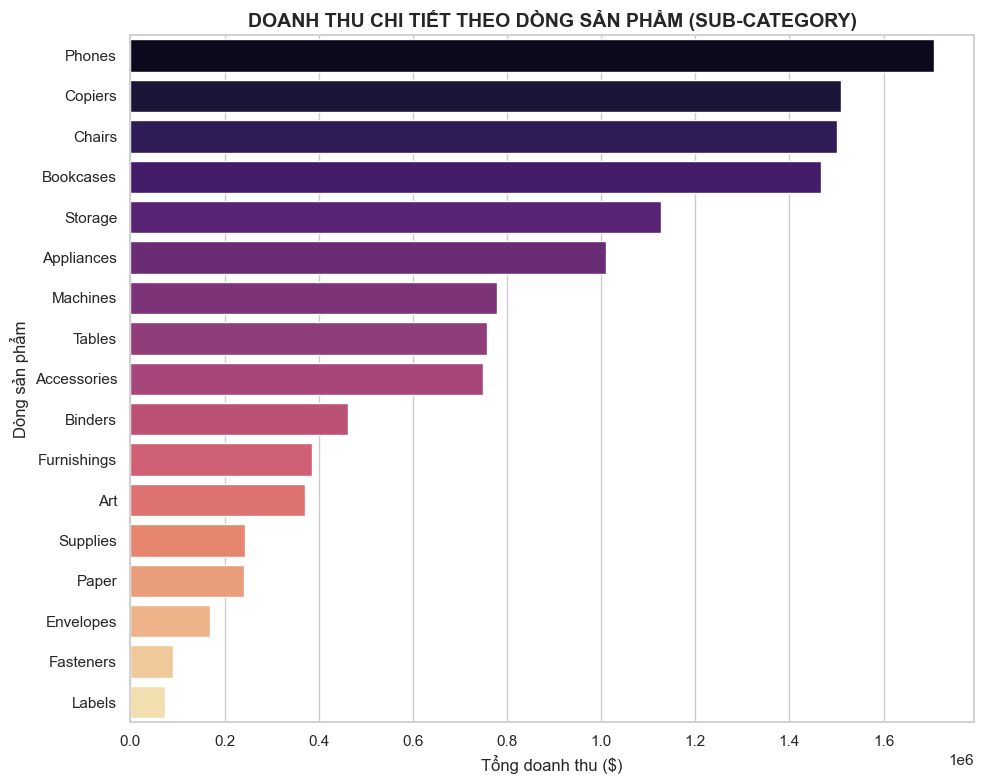

In [97]:
sub_cat_revenue = od.groupby('Sub-Category')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=sub_cat_revenue, x='Sales', y='Sub-Category', palette='magma',hue='Sub-Category')

plt.title('DOANH THU CHI TIẾT THEO DÒNG SẢN PHẨM (SUB-CATEGORY)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng doanh thu ($)')
plt.ylabel('Dòng sản phẩm')

plt.tight_layout()
plt.show()

- Phones và Copiers là hai dòng sản phẩm mang lại doanh thu lớn nhất (đều vượt ngưỡng 1.5 triệu USD). Điều này khẳng định nhóm hàng Technology dẫn đầu là nhờ các thiết bị điện tử có giá trị đơn hàng cao.
- Nhóm nội thất đóng góp khá đáng kể (Chairs, Bookcases, Tables) cho thấy nhu cầu về trang bị văn phòng và nhà ở cao
- Có một sự tương phản rõ rệt giữa nhóm đầu và nhóm cuối. Trong khi Phones mang về hàng triệu USD, thì các dòng như Labels (Nhãn dán) hay Fasteners (Kẹp/Ghim) có doanh thu cực thấp. Điều này cho thấy chiến lược doanh thu của công ty dựa trên các sản phẩm giá trị cao thay vì các mặt hàng phụ kiện nhỏ lẻ.

Doanh thu và lợi nhuận theo dòng sản phẩm

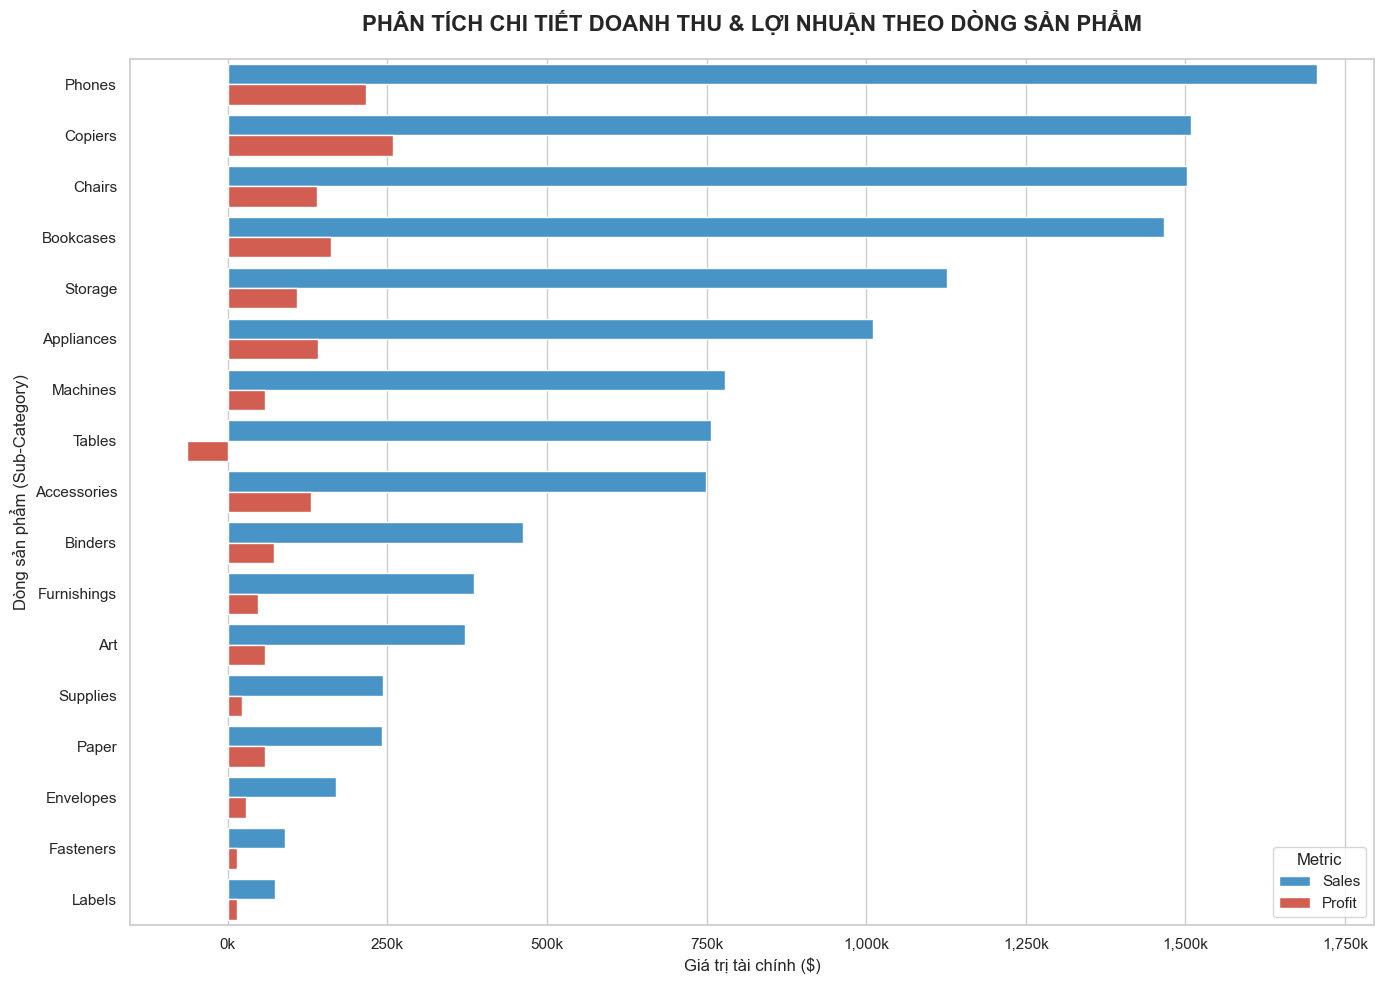


Bảng thống kê chi tiết:
Sub-Category      Sales    Profit  Profit_Margin_%
       Paper  241787.67  58111.27        24.034009
      Labels   73350.55  14988.80        20.434475
 Accessories  749237.28 129626.44        17.301120
     Copiers 1509436.51 258567.63        17.130077
   Envelopes  169217.58  28849.26        17.048619
     Binders  461870.09  72432.92        15.682531
         Art  371613.70  57829.90        15.561832
   Fasteners   89495.19  13844.08        15.469077
  Appliances 1010535.76 141562.63        14.008671
      Phones 1706824.65 216717.44        12.697112
 Furnishings  385156.15  46845.56        12.162745
   Bookcases 1466572.55 161924.37        11.041006
     Storage 1126813.78 108416.94         9.621549
      Chairs 1501682.16 140396.24         9.349265
    Supplies  242811.14  22559.04         9.290776
    Machines  779060.32  58867.70         7.556244
      Tables  757042.17 -64083.55        -8.464991


In [98]:
analysis = od.groupby('Sub-Category')[['Sales', 'Profit']].sum().reset_index()
analysis = analysis.sort_values('Sales', ascending=False)
melted_df = analysis.melt(id_vars='Sub-Category', var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")
plot = sns.barplot(data=melted_df, x='Value', y='Sub-Category', hue='Metric', palette=['#3498db', '#e74c3c'])
plt.title('PHÂN TÍCH CHI TIẾT DOANH THU & LỢI NHUẬN THEO DÒNG SẢN PHẨM', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Giá trị tài chính ($)', fontsize=12)
plt.ylabel('Dòng sản phẩm (Sub-Category)', fontsize=12)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}k".format(x/1e3)))
plt.tight_layout()
plt.show()
analysis['Profit_Margin_%'] = (analysis['Profit'] / analysis['Sales']) * 100
print("\nBảng thống kê chi tiết:")
print(analysis.sort_values('Profit_Margin_%', ascending=False)
      [['Sub-Category', 'Sales', 'Profit', 'Profit_Margin_%']]
      .to_string(index=False))

- Từ bảng thống kê có thể thấy rõ sự khác biệt giữa doanh thu và phần trăm lợi nhuận của các nhóm sản phẩm
- Một số nhóm sản phẩm như Paper và Labels có phần trăm lợi nhuận cao (24% và 20%) cho thấy khả năng kiểm soát chi phí tốt và mang lại hiệu quả kinh doanh cao. Bên cạnh đó Copier là nhóm sản phẩm nổi bật khi vừa đạt doanh thu cao và lợi nhuận cao
- Phones, Chairs, Storage là các nhóm sản phẩm có doanh thu cao nhưng phần trăm lợi nhuận lại thấp. Điều này cho thấy doanh nghiệp chưa có những chính sách giá tối ưu đối với sản phẩm này
- Đáng chú ý là nhóm Tables có phần trăm lợi nhuận âm (-8.46%) tức là đang kinh doanh thua lỗ. Đây là dấu hiệu cực kì báo động, doanh nghiệp cần xem xét lại chi phí, giá bán và chiến lược kinh doanh

So sánh mức giảm giá và tỷ suất lợi nhuận.

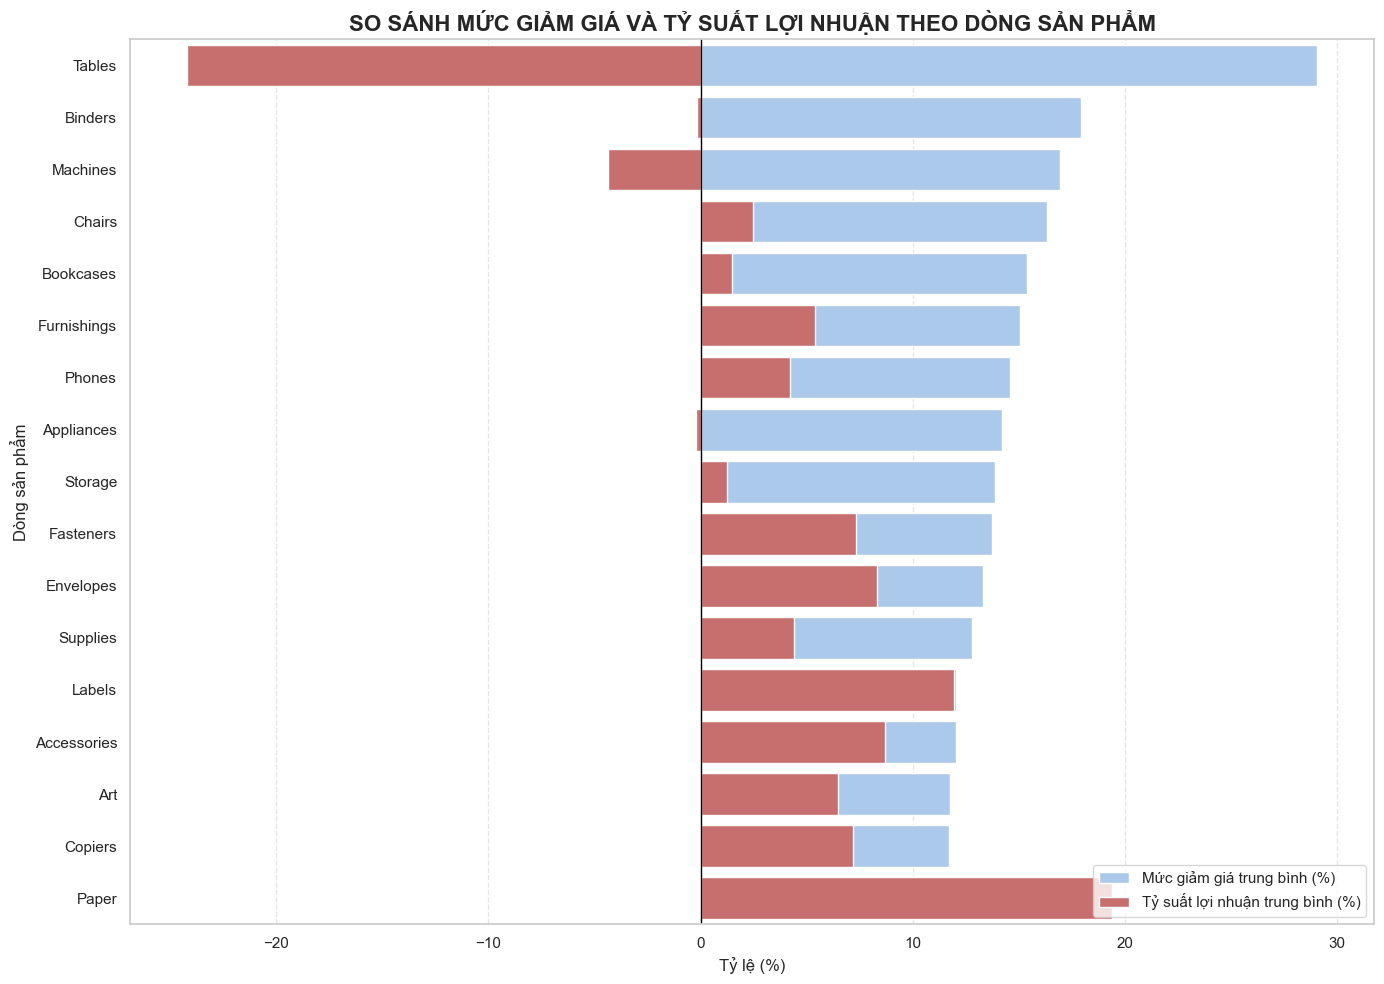


BẢNG THỐNG KÊ CHI TIẾT:
Sub-Category  Discount_%  Profit_Margin_%
      Tables   29.073171       -24.204800
     Binders   17.928409        -0.172981
    Machines   16.958277        -4.350493
      Chairs   16.311008         2.477528
   Bookcases   15.375778         1.488165
 Furnishings   15.062777         5.390950
      Phones   14.584748         4.213040
  Appliances   14.207807        -0.198507
     Storage   13.854031         1.261661
   Fasteners   13.719339         7.312973
   Envelopes   13.289066         8.292237
    Supplies   12.804321         4.412333
      Labels   12.052672        11.930966
 Accessories   12.048130         8.705600
         Art   11.757401         6.485630
     Copiers   11.714710         7.167309
       Paper   11.010882        19.371858


In [99]:
od['Profit_Margin_%'] = (od['Profit'] / od['Sales']) * 100
analysis = od.groupby('Sub-Category').agg({
    'Discount': 'mean',
    'Profit_Margin_%': 'mean'
}).reset_index()
analysis['Discount_%'] = analysis['Discount'] * 100
analysis = analysis.sort_values('Discount_%', ascending=False)
plt.figure(figsize=(14, 10))
sns.set_color_codes("pastel")
sns.barplot(x="Discount_%", y="Sub-Category", data=analysis,
            label="Mức giảm giá trung bình (%)", color="b")
sns.set_color_codes("muted")
sns.barplot(x="Profit_Margin_%", y="Sub-Category", data=analysis,
            label="Tỷ suất lợi nhuận trung bình (%)", color="r")
plt.axvline(0, color='black', lw=1)
plt.title('SO SÁNH MỨC GIẢM GIÁ VÀ TỶ SUẤT LỢI NHUẬN THEO DÒNG SẢN PHẨM', fontsize=16, fontweight='bold')
plt.xlabel('Tỷ lệ (%)', fontsize=12)
plt.ylabel('Dòng sản phẩm', fontsize=12)
plt.legend(loc="lower right", frameon=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print("\nBẢNG THỐNG KÊ CHI TIẾT:")
print(analysis[['Sub-Category', 'Discount_%', 'Profit_Margin_%']].to_string(index=False))

- Từ bảng thống kê có thể thấy quan hệ nghịch giữa mức giảm giá (Discount) và tỷ suất lợi nhuận (Profit_Margin) ở nhiều nhóm sản phẩm. Các nhóm có mức discount cao thường đi kèm với lợi nhuận thấp hoặc âm
- Tables có mức discount cao nhất (~29%) nhưng lợi nhuận âm rất lớn (-24%), cho thấy việc giảm giá mạnh khiến cho doanh nghiệp bị thua lỗ
- Binders và Machines cũng có discount cao (>16%) nhưng biên lợi nhuận thấp hoặc gần bằng 0, phản ánh hiệu quả kinh doanh kém
- Chairs và Bookcases cũng có discount tương đối cao ( 15-16%) nhưng lợi nhuận của thấp (~1-2%)
- Ngược lại, Paper có mức discount thấp nhưng tỷ suất lợi nhuận là cao nhất (~19%)

-> Discount đang ảnh hưởng tiêu cực đến lợi nhuận nếu không được kiểm soát hợp lý. Một số nhóm sản phẩm đang lạm dụng chiến lược giảm giá để thúc đẩy doanh thu nhưng làm giảm hiệu quả kinh do

Biểu đồ heatmap: Lợi nhuận theo ngành hàng và khu vực

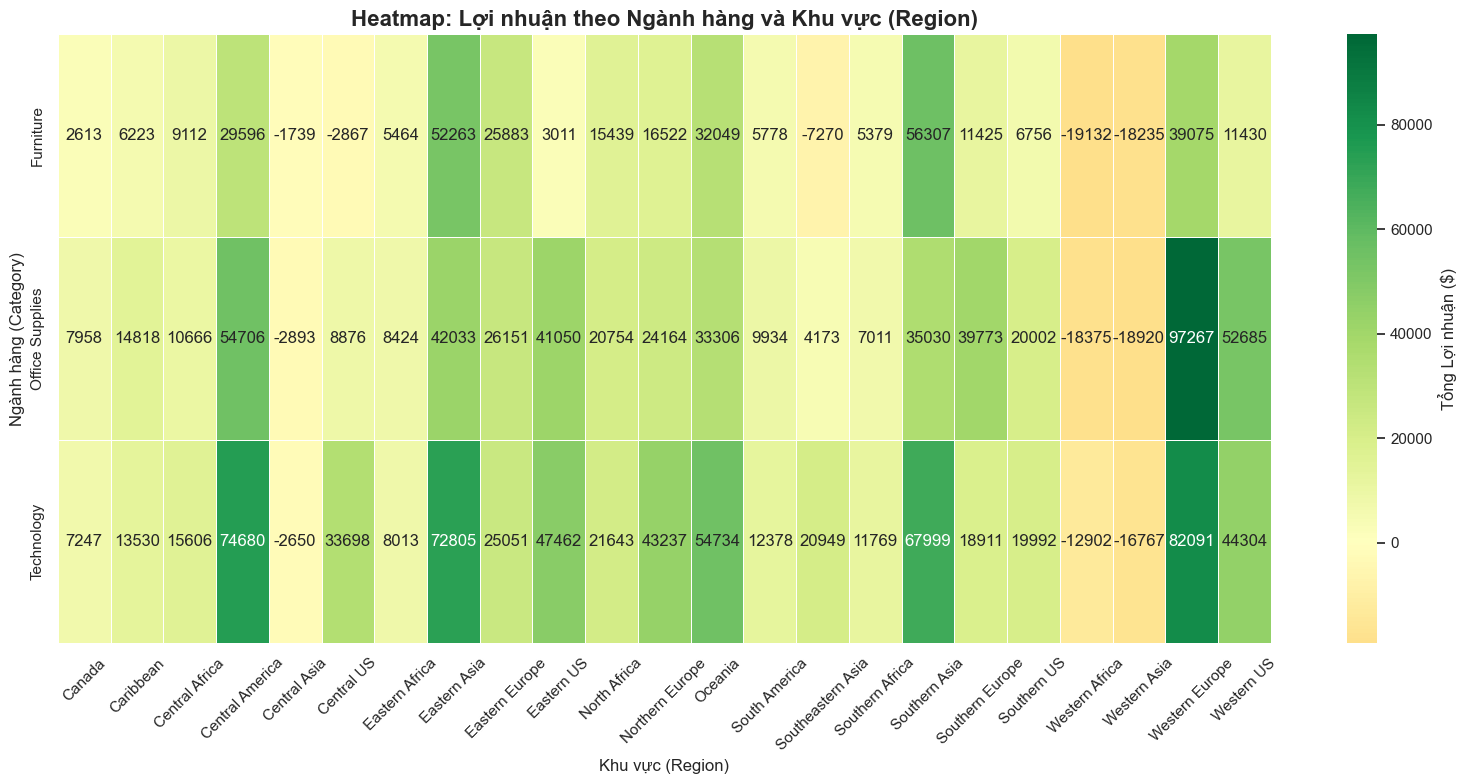


BẢNG THỐNG KÊ TỔNG LỢI NHUẬN THEO KHU VỰC:
               Region      Profit
21     Western Europe 218,433.33$
7        Eastern Asia 167,101.62$
16      Southern Asia 159,336.18$
3     Central America 158,981.81$
12            Oceania 120,089.66$
22         Western US 108,418.69$
9          Eastern US  91,522.80$
11    Northern Europe  83,923.29$
8      Eastern Europe  77,084.88$
17    Southern Europe  70,109.35$
10       North Africa  57,836.25$
18        Southern US  46,749.69$
5          Central US  39,706.44$
2      Central Africa  35,383.71$
1           Caribbean  34,571.35$
13      South America  28,090.48$
15    Southern Africa  24,158.55$
6      Eastern Africa  21,900.87$
14  Southeastern Asia  17,852.34$
0              Canada  17,817.39$
4        Central Asia  -7,282.06$
19     Western Africa -50,408.25$
20       Western Asia -53,921.70$


In [100]:
heatmap_region = od.pivot_table(index='Category',
                                columns='Region',
                                values='Profit',
                                aggfunc='sum')

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_region, annot=True, fmt=".0f", cmap='RdYlGn', center=0,
            linewidths=.5, cbar_kws={'label': 'Tổng Lợi nhuận ($)'})
plt.title('Heatmap: Lợi nhuận theo Ngành hàng và Khu vực (Region)', fontsize=16, fontweight='bold')
plt.xlabel('Khu vực (Region)', fontsize=12)
plt.ylabel('Ngành hàng (Category)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
region_profit_summary = od.groupby('Region')['Profit'].sum().reset_index()
# 3. Sắp xếp từ Lãi cao nhất đến Lỗ nặng nhất
region_profit_summary = region_profit_summary.sort_values('Profit', ascending=False)
print("\nBẢNG THỐNG KÊ TỔNG LỢI NHUẬN THEO KHU VỰC:")
print(region_profit_summary.to_string(
    formatters={'Profit': '{:,.2f}$'.format}
))

- Lợi nhuận có sự phân hóa rõ rệt giữa các khu vực và ngành hàng
- Lãi cao tập trung chủ yếu ở ngành hàng Technology và Office Supplies tại các thị trường phát triển
- Ngành hàng Furniture chịu lỗ nhiều nhất, đặc biệt tại khu vực Western Africa( -19132$) và  Western Asia(-18235$). Đây cũng là 2 khu vực lỗ nặng nhất ở cả 3 ngành hàng. Furniture thường có kích thước lớn, nặng. Nếu bán ở những vùng có cơ sở hạ tầng giao thông chưa phát triển hoặc địa hình phức tạp, phí giao hàng sẽ "ngốn" sạch lợi nhuận.
- Western Europe và Eastern Asia ( điển hình như Trung Quốc, Nhật Bản, Hàn Quốc, Anh, Pháp, Đức) và 2 khu vực có lợi nhuận cao nhất. Đây là những thị trường có nền kinh tế lớn mạnh, khách hàng sẵn sàng chi trả cho những sản phẩm có giá trị cao.

Ma trận tương quan giữa các biến số Sales, Quantity, Discount, Shipping Cost và Profit.

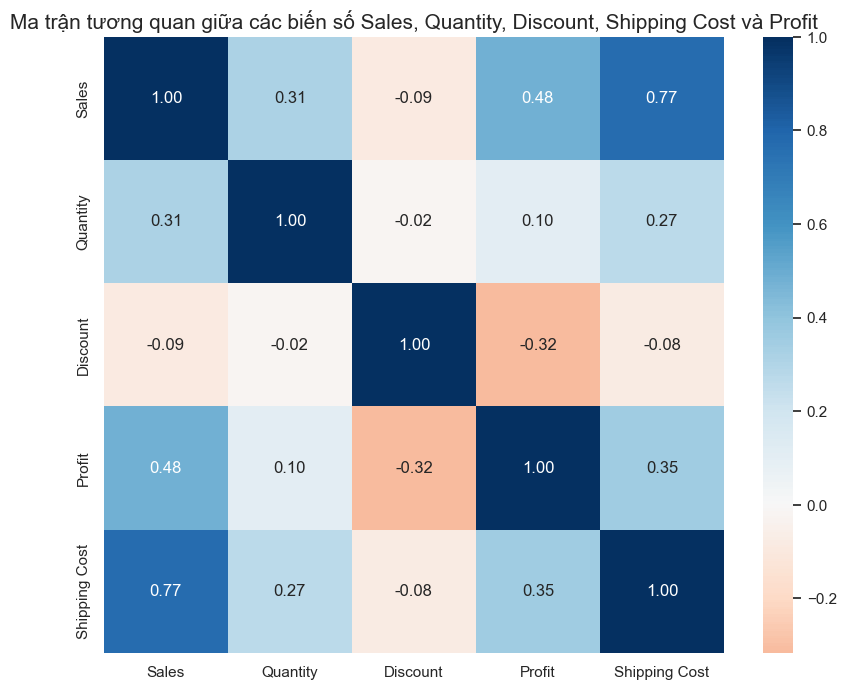

In [101]:
cols_to_analyze = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']
corr_matrix = od[cols_to_analyze].corr()
%matplotlib inline
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title('Ma trận tương quan giữa các biến số Sales, Quantity, Discount, Shipping Cost và Profit', fontsize=15)
plt.show()

- Hệ số tương quan giữa Discount và Profit là -0.32, thể hiện mối quan hệ nghịch biến rõ rệt. Đây là một trong những chỉ số quan trọng nhất ảnh hưởng đến hiệu quả kinh doanh. Chính sách chiết khấu đang trực tiếp làm giảm biên lợi nhuận.
- Hệ số giữa Discount và Sales là -0.09 là mức cực thấp( gần bằng 0). Thông thường, chúng ta giảm giá để tăng doanh số nhưng ở đây hệ số -0.09 cho thấy việc tăng chiết khấu không giúp doanh thu (Sales) tăng lên một cách rõ rệt, thậm chí nó còn có xu hướng làm giảm nhẹ tổng giá trị doanh thu.
- Mô hình kinh doanh phụ thuộc nặng nề vào việc kiểm soát Shipping Cost vì nó gắn liền với Sales (0.77). Bất kỳ sự tối ưu nào về vận chuyển cũng tác động lớn đến lợi nhuận
- Cần xem xét kĩ lại chế độ giảm giá. Dữ liệu cho thấy giảm giá dang phản tác dụng, không tăng được số bán, không tăng được doanh thu nhưng lại trực tiếp cắt giảm lợi nhuận.

Tỷ lệ trả hàng theo từng dòng sản phẩm

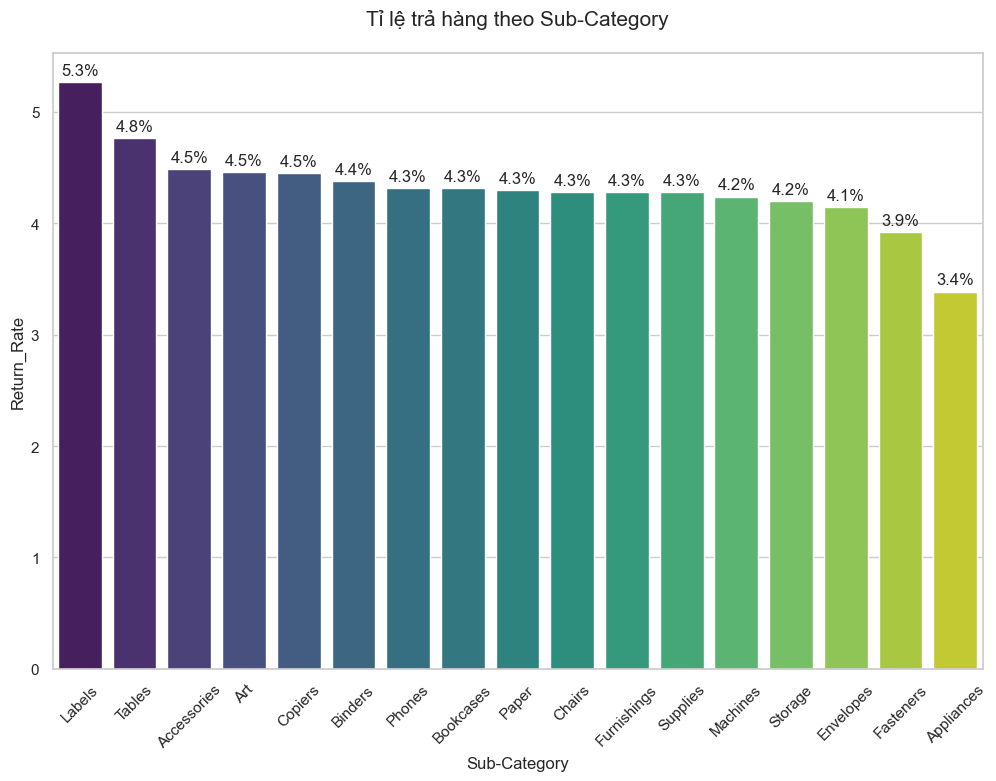

In [102]:
df_merged = pd.merge(od, rt[['Order ID', 'Returned']], on='Order ID', how='left')
df_merged['Returned'] = df_merged['Returned'].fillna('No')
stats = df_merged.groupby('Sub-Category').apply(
    lambda x: (x['Returned'] == 'Yes').sum() / len(x) * 100
).reset_index(name='Return_Rate')
stats = stats.sort_values('Return_Rate', ascending=False)
plt.figure(figsize=(12,8))
ax = sns.barplot(
    data=stats,
    x='Sub-Category',
    y='Return_Rate',
    palette='viridis',
    hue='Sub-Category',
    legend=False
)
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=3)
plt.xticks(rotation=45)
plt.title('Tỉ lệ trả hàng theo Sub-Category', fontsize=15, pad=20)
plt.show()

- Tất cả sản phẩm đều có tỉ lệ trả hàng thấp ( dưới 6%). Đây là một con số cực kỳ lý tưởng với doanh nghiệp bán lẻ toàn cầu. Chứng tỏ rằng rủi ro từ việc trả hàng không phải là nguyên nhân dẫn đến sự sụt giảm lợi nhuận ở các khu vực lỗ.

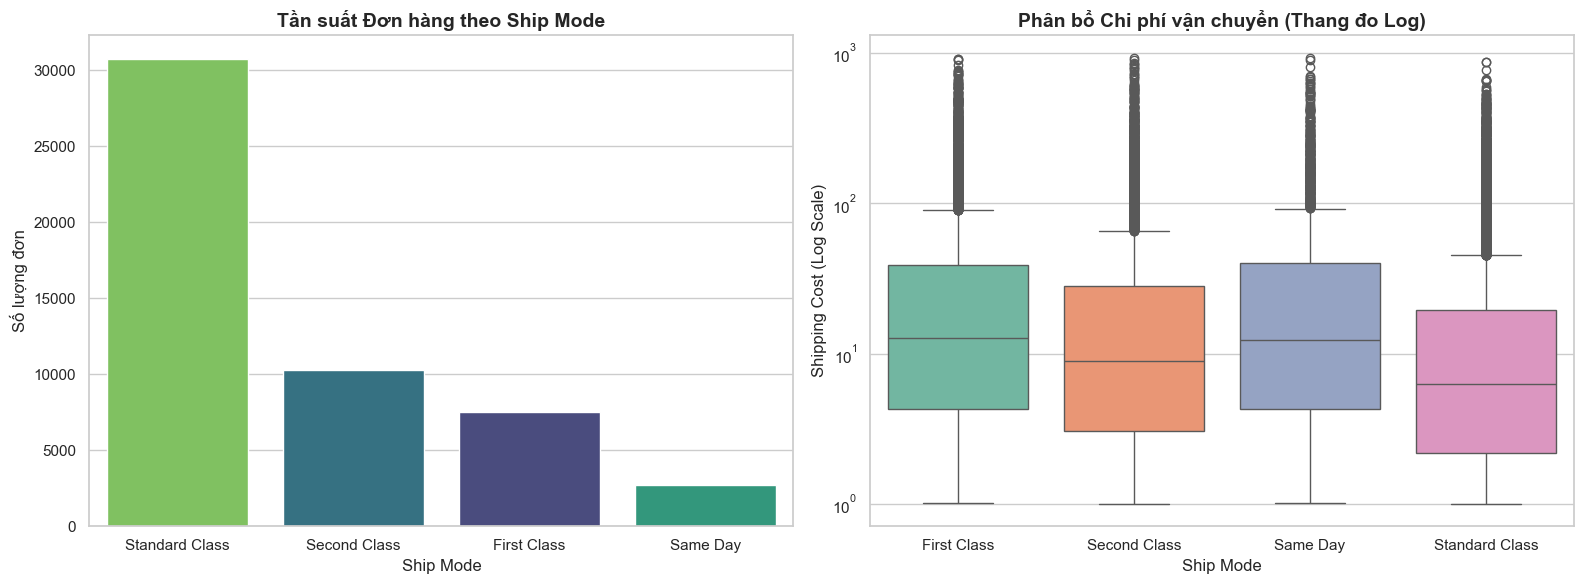

In [103]:

od['Shipping Cost'] = pd.to_numeric(od['Shipping Cost'], errors='coerce')

# 3. Khởi tạo biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- BIỂU ĐỒ 1: Số lượng đơn hàng (Quy mô) ---
sns.countplot(data=od, x='Ship Mode', hue='Ship Mode',
              order=od['Ship Mode'].value_counts().index,
              ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Tần suất Đơn hàng theo Ship Mode', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng đơn')

# --- BIỂU ĐỒ 2: Phân bổ Chi phí (Bản chất chi phí) ---
# Dùng thang đo Log để gom các giá trị "khủng" lại cho dễ nhìn
sns.boxplot(data=od, x='Ship Mode', y='Shipping Cost', hue='Ship Mode',
            ax=axes[1], palette='Set2', legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Phân bổ Chi phí vận chuyển (Thang đo Log)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Shipping Cost (Log Scale)')

plt.tight_layout()
plt.show()

- Standard Class (Giao hàng tiêu chuẩn): Chiếm tỷ trọng lớn nhất, Chi phí thấp nhất và ổn định nhất thân hộp trên biểu đồ Log-scale nằm ở vùng đáy.
- Second Class (Giao hàng tiêu chuẩn): Chi phí cao hơn Standard nhưng vẫn nằm trong tầm kiểm soát, ít biến động cực đoan. Phân khúc vận chuyển an toàn, ít gây đột biến về chi phí vận hành, giúp duy trì biên lợi nhuận (Margin) ở mức trung bình khá.
- First Class (Giao hàng ưu tiên): Tốc độ nhanh, chi phí bắt đầu có sự nhảy vọt. Chi phí thân hộp bị đẩy lên cao rõ rệt trên thang đo Log; xuất hiện nhiều đơn hàng phí ship đắt đỏ.
- Same Day (Giao hàng hỏa tốc): Tốc độ tối đa, số lượng đơn hàng thấp nhất. Chi phí và xác suất rủi ro cao nhất. Mặt bằng chi phí mặc định rất đắt đỏ, nhiều điểm ngoại lai (outliers) cực đoan.


Mô hình Prophet

In [104]:
# 1. DINH NGHIA HOLIDAYS
mid_year_sale = pd.DataFrame({
    'holiday': 'mid_year_sale',
    'ds': pd.to_datetime(['2012-06-15', '2013-06-15', '2014-06-15', '2015-06-15']),
    'lower_window': -3,
    'upper_window': 3,
})

black_friday = pd.DataFrame({
    'holiday': 'black_friday',
    'ds': pd.to_datetime(['2012-11-23', '2013-11-29', '2014-11-28', '2015-11-27']),
    'lower_window': 0,
    'upper_window': 1,
})

christmas_newyear = pd.DataFrame({
    'holiday': 'christmas_newyear',
    'ds': pd.to_datetime(['2012-12-25', '2013-12-25', '2014-12-25', '2015-12-25']),
    'lower_window': -3,
    'upper_window': 1,
})
#Gộp lại toàn bộ holiday
holidays_df = pd.concat(
    [mid_year_sale, black_friday, christmas_newyear],
    ignore_index=True
)

# 2. CHUAN BI DU LIEU MONTHLY REGION TU od
date_col = 'Order Date'
if 'Order-Date' in od.columns:
    date_col = 'Order-Date'

od[date_col] = pd.to_datetime(od[date_col], errors='coerce')
od['Sales'] = pd.to_numeric(od['Sales'], errors='coerce')

df = od.dropna(subset=[date_col, 'Region', 'Sales'])
# Doanh thu theo từng tháng trên từng khu vực
monthly = (
    df.groupby([pd.Grouper(key=date_col, freq='MS'), 'Region'], as_index=False)
      .agg(Sales=('Sales', 'sum'))
      .rename(columns={date_col: 'ds', 'Region': 'region', 'Sales': 'y'})
)

all_regions = sorted(monthly['region'].unique())
all_months = pd.date_range(monthly['ds'].min(), monthly['ds'].max(), freq='MS')

full_index = pd.MultiIndex.from_product(
    [all_months, all_regions],
    names=['ds', 'region']
).to_frame(index=False)

monthly_full = full_index.merge(monthly, on=['ds', 'region'], how='left')
monthly_full['y'] = monthly_full['y'].fillna(0)

# 3. CHIA MOC THOI GIAN
valid_cutoff = pd.Timestamp('2014-07-01')
test_cutoff = pd.Timestamp('2015-01-01')

def wape(y_true, y_pred):
    denom = np.abs(y_true).sum()
    if denom == 0:
        return np.nan
    return np.abs(y_true - y_pred).sum() / denom * 100
# 4. HAM TRAIN NHANH CHO TUNG REGION
def train_prophet_region_fast(region_df, region_name, holidays_df):
    region_df = region_df.sort_values('ds').copy() # Sắp xếp đúng thứ tự thời gian trước khi chia tập
    # Tách train, valid, test theo mốc thời gian
    train = region_df[region_df['ds'] < valid_cutoff][['ds', 'y']].copy()
    valid = region_df[(region_df['ds'] >= valid_cutoff) & (region_df['ds'] < test_cutoff)][['ds', 'y']].copy()
    test  = region_df[region_df['ds'] >= test_cutoff][['ds', 'y']].copy()
    # Bỏ qua nếu dữ liệu vùng quá ít, tránh train mô hình không đáng tin
    if len(train) < 18 or len(valid) < 3 or len(test) < 3:
        return None

    train_valid = pd.concat([train, valid], ignore_index=True) # gộp train và valid

   # Khởi tạo Prophet:
    model = Prophet(
        holidays=holidays_df,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05
    )

    model.fit(train_valid)

    forecast_test = model.predict(test[['ds']])

    result = test[['ds']].copy()
    result['region'] = region_name
    result['Actual'] = test['y'].values
    result['Pred'] = forecast_test['yhat'].values

    metrics = {
        'Region': region_name,
        'R2': r2_score(result['Actual'], result['Pred']),
        'MAE': mean_absolute_error(result['Actual'], result['Pred']),
        'RMSE': np.sqrt(mean_squared_error(result['Actual'], result['Pred'])),
        'WAPE': wape(result['Actual'], result['Pred'])
    }

    return {
        'model': model,
        'forecast': result,
        'metrics': metrics
    }
# 5. CHAY CHO TAT CA REGION
all_results = []
all_forecasts = []
all_models = {}

for region in all_regions:
    # Lấy riêng dữ liệu của từng khu vực
    region_df = monthly_full[monthly_full['region'] == region].copy()
    res = train_prophet_region_fast(region_df, region, holidays_df)

    if res is not None:
        all_models[region] = res['model']
        all_results.append(res['metrics'])
        all_forecasts.append(res['forecast'])
# Gộp kết quả tất cả khu vực
results_prophet_fast = pd.DataFrame(all_results).sort_values('WAPE')
forecast_prophet_fast = pd.concat(all_forecasts, ignore_index=True)

# 6. METRIC THEO TUNG REGION
print("=== KET QUA THEO TUNG REGION ===")
print(results_prophet_fast[['Region', 'R2', 'MAE', 'RMSE', 'WAPE']])

# =========================================================
# 7. METRIC TONG HOP TOAN BO REGION
# =========================================================
overall_r2 = r2_score(forecast_prophet_fast['Actual'], forecast_prophet_fast['Pred'])
overall_mae = mean_absolute_error(forecast_prophet_fast['Actual'], forecast_prophet_fast['Pred'])
overall_rmse = np.sqrt(mean_squared_error(forecast_prophet_fast['Actual'], forecast_prophet_fast['Pred']))
overall_wape = wape(forecast_prophet_fast['Actual'], forecast_prophet_fast['Pred'])

print("\n=== KET QUA TONG HOP PROPHET REGION-MONTH ===")
print(f"R2   : {overall_r2:.4f}")
print(f"MAE  : {overall_mae:.2f}")
print(f"RMSE : {overall_rmse:.2f}")
print(f"WAPE : {overall_wape:.2f}%")

10:12:53 - cmdstanpy - INFO - Chain [1] start processing
10:12:53 - cmdstanpy - INFO - Chain [1] done processing
10:12:53 - cmdstanpy - INFO - Chain [1] start processing
10:12:54 - cmdstanpy - INFO - Chain [1] done processing
10:12:54 - cmdstanpy - INFO - Chain [1] start processing
10:12:54 - cmdstanpy - INFO - Chain [1] done processing
10:12:54 - cmdstanpy - INFO - Chain [1] start processing
10:12:55 - cmdstanpy - INFO - Chain [1] done processing
10:12:55 - cmdstanpy - INFO - Chain [1] start processing
10:12:55 - cmdstanpy - INFO - Chain [1] done processing
10:12:56 - cmdstanpy - INFO - Chain [1] start processing
10:12:56 - cmdstanpy - INFO - Chain [1] done processing
10:12:56 - cmdstanpy - INFO - Chain [1] start processing
10:12:57 - cmdstanpy - INFO - Chain [1] done processing
10:12:57 - cmdstanpy - INFO - Chain [1] start processing
10:12:58 - cmdstanpy - INFO - Chain [1] done processing
10:12:58 - cmdstanpy - INFO - Chain [1] start processing
10:12:59 - cmdstanpy - INFO - Chain [1]

=== KET QUA THEO TUNG REGION ===
               Region        R2           MAE          RMSE        WAPE
3     Central America  0.688740   7037.553159   9467.498968   21.680524
21     Western Europe  0.623666  11120.069778  12923.458546   22.134579
12            Oceania  0.531908   6694.055026   8061.195162   22.163898
16      Southern Asia  0.175482   7069.694048   8470.144582   28.529521
7        Eastern Asia  0.186593   6387.203460   7555.879335   28.798399
22         Western US -0.015303   6231.626954   7101.178251   29.836320
19     Western Africa -0.287352   1868.677366   2524.239321   33.974032
14  Southeastern Asia -0.400223   9298.022335  10861.555410   34.536414
8      Eastern Europe -1.126987   3939.339556   5712.726849   39.326305
11    Northern Europe -0.850544   7950.641872  10073.414775   40.182971
17    Southern Europe  0.060883   7394.300986   8581.819101   40.368247
1           Caribbean  0.150602   3575.071053   4326.426448   40.667557
10       North Africa -0.098187

Mô hình Prophet cho kết quả tổng thể khá tích cực ở cấp độ doanh thu khu vực-tháng, với R2 = 0.7486, cho thấy khả năng nắm bắt xu hướng và mùa vụ tương đối tốt. Tuy nhiên, khi phân tích chi tiết theo từng khu vực, hiệu quả dự báo có sự phân hóa rõ rệt. Mô hình hoạt động tốt tại các khu vực có quy mô doanh thu lớn và xu hướng ổn định như Central America, Western Europe và Oceania, nhưng cho kết quả kém ở nhiều khu vực còn lại, thể hiện qua hệ số R2 âm và WAPE cao. Điều này cho thấy Prophet phù hợp hơn với các chuỗi ổn định, nhưng chưa đảm bảo tính nhất quán trên toàn bộ hệ thống đa khu vực.Vì vậy, nghiên cứu quyết định chọn XGBoost làm mô hình dự báo chính. Lý do là XGBoost linh hoạt hơn trong việc học từ các biến trễ, xu hướng ngắn hạn và sự khác nhau giữa các khu vực, nên phù hợp hơn với mục tiêu xây dựng một mô hình dự báo dùng chung cho toàn bộ dữ liệu.

Mô hình XGBoost

Trong quá trình xây dựng mô hình, nghiên cứu đã thử nghiệm bổ sung các biến Discount, Quantity và Shipping Cost nhằm kiểm tra khả năng cải thiện độ chính xác dự báo doanh thu. Tuy nhiên, kết quả thực nghiệm cho thấy các biến này không mang lại giá trị dự báo bổ sung đáng kể so với bộ biến cơ sở dựa trên lịch sử doanh thu, mùa vụ và vùng địa lý. Cụ thể, Quantity chỉ cải thiện hiệu năng ở mức rất nhỏ, trong khi Discount và Shipping Cost không cải thiện, thậm chí có xu hướng làm mô hình kém ổn định hơn. Điều này cho thấy phần lớn thông tin hữu ích của các biến trên đã được phản ánh gián tiếp qua các biến doanh thu trễ. Vì vậy, nghiên cứu quyết định loại bỏ các biến này khỏi mô hình cuối cùng nhằm ưu tiên tính gọn nhẹ, ổn định và khả năng diễn giải của mô hình mà vẫn đảm bảo hiệu quả dự báo.


📊 XGBOOST MONTHLY RESULTS 
R2 Score : 0.6070
MAE      : 4080.15
WAPE     : 31.45%
Best iteration: 170


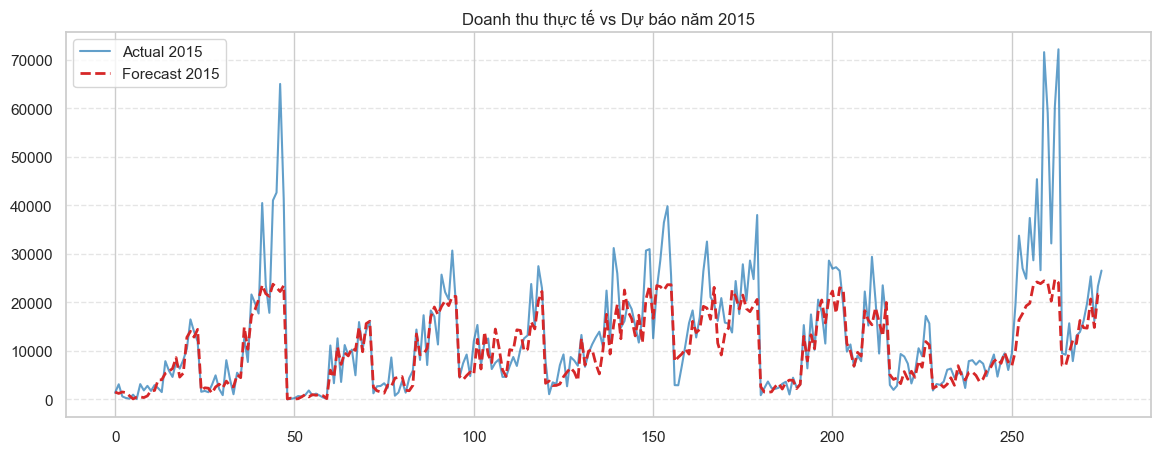

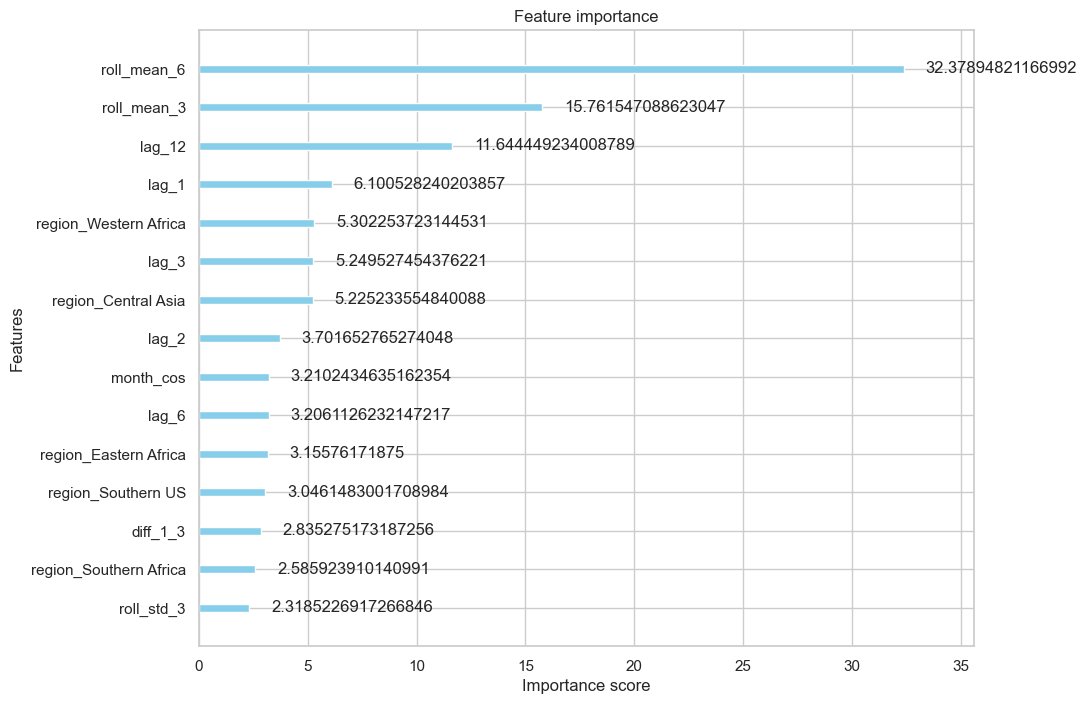

In [105]:
# 1. TIỀN XỬ LÝ DỮ LIỆU GỐC
valid_cutoff = '2014-07-01'
test_cutoff = '2015-01-01'

# Xử lý Outlier dựa trên dữ liệu trước Test
sales_limit = od.loc[od['Order Date'] < test_cutoff, 'Sales'].quantile(0.95)
od['Sales_Cleaned'] = od['Sales'].clip(upper=sales_limit)

# Gộp theo tháng và vùng
monthly = (
    od.groupby([pd.Grouper(key='Order Date', freq='MS'), 'Region'])['Sales_Cleaned']
      .sum()
      .reset_index()
      .rename(columns={'Order Date': 'ds', 'Region': 'region', 'Sales_Cleaned': 'y'})
)

# Bổ sung đầy đủ các tháng (Gán y=0 cho tháng trống)
all_regions = monthly['region'].unique()
all_months = pd.date_range(monthly['ds'].min(), monthly['ds'].max(), freq='MS')
full_index = pd.MultiIndex.from_product([all_months, all_regions], names=['ds', 'region'])
monthly_full = monthly.set_index(['ds', 'region']).reindex(full_index).fillna(0).reset_index()

# 2. HÀM TẠO ĐẶC TRƯNG (FEATURE ENGINEERING)
def make_monthly_features(df):
    df = df.copy().sort_values(['region', 'ds'])

    # Time features
    df['month'] = df['ds'].dt.month
    df['quarter'] = df['ds'].dt.quarter
    df['year'] = df['ds'].dt.year
    #Mùa vụ dạng chu kỳ giúp mô hình hiểu tháng 12 gần tháng 1
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['y_log'] = np.log1p(df['y'])

    # Lags (Biến trễ)
    # Log transform giảm độ lệch dữ liệu để giúp mô hình học tốt hơn
    # Chuyển bài toán tự sai số giá trị tuyệt đối sang sai số tỷ lệ phần trăm
    for l in [1, 2, 3, 6, 12]:
        df[f'lag_{l}'] = df.groupby('region')['y_log'].shift(l)

    # Rolling (Trung bình  3, 6 tháng và độ lệch chuẩn 3 tháng gần nhất)
    df['roll_mean_3'] = df.groupby('region')['lag_1'].transform(lambda x: x.rolling(3).mean())
    df['roll_mean_6'] = df.groupby('region')['lag_1'].transform(lambda x: x.rolling(6).mean())
    df['roll_std_3'] = df.groupby('region')['lag_1'].transform(lambda x: x.rolling(3).std())

    # đo tốc độ tăng/giảm doanh thu
    df['diff_1_3'] = df['lag_1'] - df['lag_3']
    df['diff_1_12'] = df['lag_1'] - df['lag_12']

    # One-hot region chuyển sang dạng số
    df = pd.get_dummies(df, columns=['region'], drop_first=True, dtype=int)

    return df.dropna() # vì lag và rolling tạo giá trị NaN ở đầu chuỗi

# 3. CHIA DỮ LIỆU & TẠO FEATURE

# Bước A: Tách dữ liệu quá khứ (Train + Valid)
# Dùng để huấn luyện và tối ưu siêu tham số mà không nhìn trước tập Test
raw_train_val = monthly_full[monthly_full['ds'] < test_cutoff].copy()
train_val_ready = make_monthly_features(raw_train_val)

# Bước B: Xử lý tập Test bằng kỹ thuật "Mồi dữ liệu"

# Lấy 12 tháng cuối của tập cũ để làm "điểm tựa" tính toán các biến trễ (Lag, Rolling)
# Cần lấy (Số vùng * 12 tháng) để đảm bảo tất cả các vùng đều đủ dữ liệu quá khứ
test_combined = pd.concat([raw_train_val.tail(len(all_regions) * 12), monthly_full[monthly_full['ds'] >= test_cutoff]])
# Tạo feature trên tập kết hợp để tránh lỗi NaN ở các dòng đầu tập Test
test_ready = make_monthly_features(test_combined)
# Loại bỏ phần dữ liệu mồi, chỉ giữ lại đúng khung thời gian của tập Test để đánh giá
test_ready = test_ready[test_ready['ds'] >= test_cutoff]

# Bước C: Chia nhỏ tập Train/Valid để thực hiện đánh giá mô hình và tìm bộ thông số tốt nhất cho mô hình
train_df = train_val_ready[train_val_ready['ds'] < valid_cutoff].copy()
valid_df = train_val_ready[train_val_ready['ds'] >= valid_cutoff].copy()
test_df  = test_ready.copy()

# Xác định danh sách Features
cols_to_drop = ['ds', 'y', 'y_log']
features = [c for c in train_df.columns if c not in cols_to_drop]

# Ép kiểu float hoàn toàn để tránh lỗi kiến trúc
X_train, y_train = train_df[features].astype(float), train_df['y_log']
X_valid, y_valid = valid_df[features].astype(float), valid_df['y_log']
X_test, y_test   = test_df[features].astype(float), test_df['y']

# 4. HUẤN LUYỆN XGBOOST
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=1,
    reg_lambda=8,
    random_state=42,
    early_stopping_rounds=60
)
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# 5. DỰ BÁO & ĐÁNH GIÁ
y_pred = np.expm1(model_xgb.predict(X_test.values))
# Vì mô hình học trên log(y), nên dùng expm1() để chuyển dự báo về lại thang doanh thu ban đầu.
# Metrics
def wape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum() * 100
print("\n" + "="*30)
print("📊 XGBOOST MONTHLY RESULTS ")
print(f"R2 Score : {r2_score(y_test, y_pred):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"WAPE     : {wape(y_test, y_pred):.2f}%")
print(f"Best iteration: {model_xgb.best_iteration}")
print("="*30)

# 6. VẼ BIỂU ĐỒ
plt.figure(figsize=(14, 5))
plt.plot(y_test.values, label='Actual 2015', color='tab:blue', alpha=0.7)
plt.plot(y_pred, label='Forecast 2015', color='tab:red', linewidth=2, linestyle='--')
plt.title('Doanh thu thực tế vs Dự báo năm 2015')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model_xgb, importance_type='gain', max_num_features=15, ax=ax, color='skyblue')
plt.show()

Khi chuyển sang dự báo theo tháng, hiệu quả mô hình được cải thiện rõ rệt với R2 tăng mạnh và WAPE giảm đáng kể. Điều này cho thấy việc tổng hợp dữ liệu theo tháng đã giúp giảm bớt nhiễu ngắn hạn, làm nổi bật hơn xu hướng và yếu tố mùa vụ. Ở cấp độ tháng-vùng, mô hình XGBoost khai thác tốt hơn thông tin từ các biến trễ, rolling features và đặc điểm vùng địa lý, từ đó cho kết quả ổn định và chính xác hơn. Kết quả này cho thấy dự báo theo tháng là cấp độ phù hợp hơn cho bài toán dự báo doanh thu trong bộ dữ liệu Global Superstore.

Mô hình tối ưu hóa biên lợi n

R2 Score (Margin): 0.8017
MAE (Margin): 0.1600
Best Iteration: 118


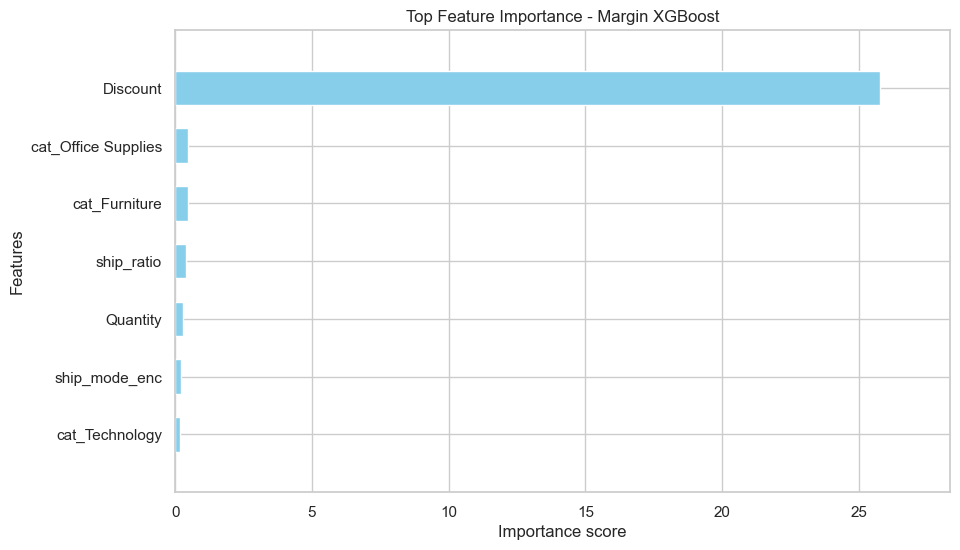

In [106]:
# 1. TIỀN XỬ LÝ DỮ LIỆU GỐC
# Chuyển đổi các cột số (ép kiểu để tránh lỗi định dạng chuỗi)
cols_to_fix = ['Sales', 'Profit', 'Shipping Cost', 'Discount']
for col in cols_to_fix:
    od[col] = pd.to_numeric(od[col], errors='coerce')

# Loại bỏ các dòng bị trống dữ liệu quan trọng
od = od.dropna(subset=cols_to_fix)

#  BƯỚC 1: TẠO BIẾN MỤC TIÊU (TARGET)
df_margin = od.copy()
df_margin['target_margin'] = df_margin['Profit'] / df_margin['Sales']

# BƯỚC 2: XỬ LÝ BIẾN ĐẦU VÀO (FEATURES)
# 1. Mã hóa Ship Mode theo thứ tự (Ordinal Encoding)
ship_map = {'Standard Class': 0, 'Second Class': 1, 'First Class': 2, 'Same Day': 3}
df_margin['ship_mode_enc'] = df_margin['Ship Mode'].map(ship_map)

# 2. Tạo biến Shipping Cost Ratio (Tỷ lệ chi phí ship trên doanh thu)
df_margin['ship_ratio'] = df_margin['Shipping Cost'] / df_margin['Sales']

# 3. Mã hóa các biến phân loại Category (One-hot encoding)
df_margin = pd.get_dummies(df_margin, columns=['Category'], prefix='cat')

# BƯỚC 3: CHIA DỮ LIỆU (TRAIN - VALID - TEST)

valid_cutoff = '2014-07-01'
test_cutoff = '2015-01-01'

train_m = df_margin[df_margin['Order Date'] < valid_cutoff].copy()
valid_m = df_margin[(df_margin['Order Date'] >= valid_cutoff) & (df_margin['Order Date'] < test_cutoff)].copy()
test_m = df_margin[df_margin['Order Date'] >= test_cutoff].copy()

# Danh sách features
features_margin = [
    'Discount', 'ship_mode_enc', 'ship_ratio', 'Quantity',
    'cat_Furniture', 'cat_Office Supplies', 'cat_Technology'
]

X_train = train_m[features_margin]
y_train = train_m['target_margin']

X_valid = valid_m[features_margin]
y_valid = valid_m['target_margin']

X_test = test_m[features_margin]
y_test = test_m['target_margin']

# --- BƯỚC 4: HUẤN LUYỆN XGBOOST
model_margin = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50
)

model_margin.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],

    verbose=False
)
# --- BƯỚC 5: DỰ BÁO & ĐÁNH GIÁ ---
y_pred = model_margin.predict(X_test)
print(f"R2 Score (Margin): {r2_score(y_test, y_pred):.4f}")
print(f"MAE (Margin): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Best Iteration: {model_margin.best_iteration}")

# BƯỚC 6: FEATURE IMPORTANCE
model_margin.get_booster().feature_names = features_margin
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(
    model_margin,
    importance_type='gain',
    max_num_features=10,
    ax=ax,
    height=0.6,
    color='skyblue',
    show_values=False
)
plt.title('Top Feature Importance - Margin XGBoost')
plt.show()

Retrain mô hình và lưu lại kết quả

In [107]:
import joblib
import json

# 1. RETRAIN MÔ HÌNH DOANH THU (SALES) - DÙNG TOÀN BỘ DATA
# Tạo dữ liệu đặc trưng sạch đến hết 2015
data_final_ready = make_monthly_features(monthly_full)

# Chuẩn bị X, y cho Sales
X_sales_final = data_final_ready[features].astype(float)
y_sales_final = data_final_ready['y_log']

# Khởi tạo mô hình Sales với tham số tối ưu (Best Iteration = 170)
model_sales_final = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=170,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=1,
    reg_lambda=8,
    random_state=42
)
model_sales_final.fit(X_sales_final, y_sales_final)

# 2. RETRAIN MÔ HÌNH BIÊN LỢI NHUẬN (MARGIN)
# Gộp tất cả các tập dữ liệu Margin lại để AI học toàn bộ kiến thức đến hết 2015
X_margin_all = pd.concat([X_train, X_valid, X_test]).astype(float)
y_margin_all = pd.concat([y_train, y_valid, y_test])

# Khởi tạo mô hình Margin Final với số vòng lặp tối ưu
best_iter_margin = model_margin.best_iteration if model_margin.best_iteration > 0 else 500

model_margin_final = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_iter_margin,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Huấn luyện trên 100% dữ liệu Margin
model_margin_final.fit(X_margin_all, y_margin_all)

# 3. LƯU MÔ HÌNH (EXPORT MODELS)
model_sales_final.save_model("models/model_monthly.json")
model_margin_final.save_model("models/model_margin.json")

# 4. LƯU FEATURES VÀ CẤU HÌNH (JSON)
# Lưu danh sách features cho Sales
with open('configs/features.json', 'w') as f:
    json.dump(list(features), f)
# Lưu danh sách features cho Margin
try:
    with open('features_margin.json', 'w') as f:
        json.dump(list(features_margin), f)
except NameError:
    pass

# Lưu các danh mục hiển thị cho giao diện Web
with open('configs/regions.json', 'w') as f:
    json.dump(all_regions.tolist(), f)

with open('configs/categories.json', 'w') as f:
    json.dump(['Furniture', 'Office Supplies', 'Technology'], f)

with open('ship_modes.json', 'w') as f:
    json.dump(['Standard Class', 'Second Class', 'First Class', 'Same Day'], f)

# 5. LƯU DỮ LIỆU LỊCH SỬ (MONTHLY HISTORY)
data_final_ready.to_csv("data/monthly_history.csv", index=False)
# Đảm bảo cột Shipping Cost là số trước khi tính toán
od['Shipping Cost'] = pd.to_numeric(od['Shipping Cost'], errors='coerce')

# Tính bảng tra cứu phí ship trung bình ($)
ship_money_profile = od.groupby(['Region', 'Category'])['Shipping Cost'].mean().reset_index()
ship_money_profile.columns = ['Region', 'Category', 'Avg_Ship_Cost_Money']

# Lưu file tra cứu số tiền
ship_money_profile.to_csv("data/ship_money_profile.csv", index=False)

# Tính bảng tra cứu tỷ lệ ship/sales (%) - Cái này dùng cho thanh trượt Slider
ship_ratio_profile = od.groupby(['Region', 'Category']).apply(
    lambda x: (x['Shipping Cost'] / x['Sales']).mean()
).reset_index(name='avg_ship_ratio')

# Lưu file tra cứu tỷ lệ
ship_ratio_profile.to_csv("data/ship_ratio_profile.csv", index=False)
# Tính doanh thu trung bình tháng của từng Category tại từng Region
cat_sales_avg = od.groupby(['Region', 'Category'])['Sales'].mean().reset_index()
cat_sales_avg.columns = ['Region', 'Category', 'Avg_Monthly_Sales']

# Lưu file
cat_sales_avg.to_csv("data/cat_sales_avg.csv", index=False)

